## Self-explanatory title. Some creation of G and J will be copied over here for the miniaste snaps.

In [90]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(450, 90)
RAC2d (40500,)
(100,)


In [91]:
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [92]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

mymsk = np.full((ny,nx),np.nan)
mymsk[ind2d == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

ind = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

In [93]:
landmsk = np.zeros((ny,nx))
landmsk[hf1 == 0] = 1
landmsk[hf1 == 1] = np.nan

In [94]:
# ok we defined mymsk, now we need to define the indices in ind where these are selected
# load the JtermsT from the function (see previous configuration of layers)

# not sure if this will be the correct way to load it but we can check
# we will use the bins from the An run so that we have the same thing in both sections
# Paths for the bins in this run
filename = "layers2TH"
boundsT = rdmds(layers_path + filename)
binsTH_edges = boundsT.reshape(boundsT.shape[0])
binsTH_centers = (binsTH_edges[:-1] + binsTH_edges[1:])/2
nT = binsTH_edges.shape[0]-1
print(nT)

filename = "layers1SLT"
boundsS = rdmds(layers_path + filename)
binsSLT_edges = boundsS.reshape(boundsS.shape[0])
binsSLT_centers = (binsSLT_edges[:-1] + binsSLT_edges[1:])/2
nS = binsSLT_edges.shape[0]-1
print(nS)

binwidthT = binsTH_edges[1:] - binsTH_edges[:-1]
print(binwidthT.shape)
binwidthS = binsSLT_edges[1:] - binsSLT_edges[:-1]

binwidthT1 = (binwidthT[:-1] + binwidthT[1:])/2
binwidthS1 = (binwidthS[:-1] + binwidthS[1:])/2

dT,dS = np.meshgrid(binwidthT,binwidthS)
dT = dT.reshape(112,112,1)
dS = dS.reshape(112,112,1)

binmidT = ((boundsT[:-1] + boundsT[1:])/2).reshape(nT)
binmidS = ((boundsS[:-1] + boundsS[1:])/2).reshape(nT)

binmidTp = boundsT[1:-1]
binmidSp = boundsS[1:-1]

Tbin,Sbin = np.meshgrid(binsTH_edges,binsSLT_edges)
Tbincent,Sbincent = np.meshgrid(binsTH_centers,binsSLT_centers)
Tbin2,Sbin2 = np.meshgrid(binmidTp,binmidSp)

112
112
(112,)


In [95]:
# we need to also create the theta and salt bins for this area
tsstr = np.array(["0000000003","0000000004"])
t2 = int(tsstr[1]) # for the offline version

### We start with the G terms for eq. 2 and eq. 3

In [96]:
# we know this to be correct from the generation of the horizontal converences of the fields. Let's create these for temperature

from create_aste90_layers import create_layers_totalTHETA

dt = 1800
termsT3D = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=True)

In [97]:
t2 = int(tsstr[1])
# 'diags/state_3d_set1'
# read theta and salt averages from the t2 timestep (average)
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz,ny,nx)
SALT = SALT.reshape(nz,ny,nx)

In [98]:
# from termsT3D, we create the G_T again. I think this can be copied over

# termsT3D.keys()

# we also returned dF_Tnew from this function
Msum,dF_Tnew = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=False)

In [99]:
# dF_Tnew contains the G terms in terms of degC.m^3/s

In [100]:
# this is basically the same for Salt. So we have eqs. 2 and 3.

## Recreate the J term based on termsT3D. And compare this to the output from layers

In [101]:
DFhT_offline = termsT3D['DFhT']                   # we can try to bin this one

In [102]:
filename = "Jy_miniaste_BarentsS.npz"
matpath = "/scratch2/mmurakami/aste_90x150x60/"
matpath += "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"

npz = np.load(matpath + filename, allow_pickle=True)

Jy = {}
Jy["unit"] = str(npz["unit"])  # stored as 0-d array / stringy object

# this is the nested dict, stored as a 0-d object array
Jy["BarentsS"] = npz["BarentsS"].item()

npz.close()

In [61]:
print(Jy['BarentsS']['0000000004'].keys())

dict_keys(['G_T', 'LTto_TS', 'LTza_TS', 'LTha_TS', 'LaTz_TS', 'LaTh_TS', 'LaTs_TS', 'residT'])


(-2.0, 8.0)

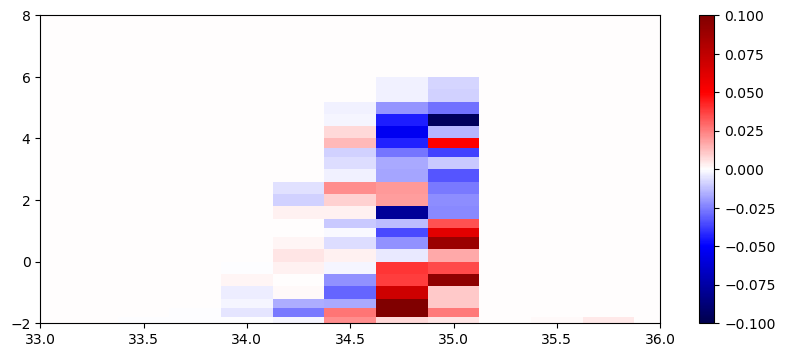

In [62]:
residT = Jy['BarentsS']['0000000004']['residT']
LTto_TS = Jy['BarentsS']['0000000004']['LTto_TS']
LaTh_TS = Jy['BarentsS']['0000000004']['LaTh_TS']

plt.pcolormesh(Sbin2,Tbin2,LaTh_TS.T,cmap='seismic',vmin=-.1,vmax=.1)
plt.colorbar()
plt.xlim(33,36)
plt.ylim(-2,8)

In [63]:
# we need to make an array of 111,111 (see next line) which is DFhT_offline binned by cell center
# this is first in units of degC.m^3/s so we need to divide by binwidthT1 and binwidthS1
mymsk3d = np.tile(mymsk[np.newaxis,:,:],(nz,1,1))

dF_TS = np.zeros((nT-1, nS-1), dtype=float)
G_TS  = np.zeros((nT-1, nS-1), dtype=float)
L_TS  = np.zeros((nT-1, nS-1), dtype=int)

# Flatten so we don't have to loop thorugh zyx
T_flat   = np.ravel(THETA * mymsk3d, order="F")
S_flat   = np.ravel(SALT  * mymsk3d, order="F")
DFh_flat = np.ravel(DFhT_offline  * mymsk3d, order="F")

# 2D binning via bin index lookup (faster than nested np.where) as in previous loop (in create_aste90_layers.py)
iT = np.searchsorted(binmidT, T_flat, side="right") - 1
iS = np.searchsorted(binmidS, S_flat, side="right") - 1

# Keep only points that land in a valid interior bin
ok = (iT >= 0) & (iT < nT-1) & (iS >= 0) & (iS < nS-1) & np.isfinite(DFh_flat)
iT = iT[ok]
iS = iS[ok]
vals = DFh_flat[ok]

# Accumulate sums and counts into (T,S) bins
np.add.at(dF_TS, (iT, iS), vals)
np.add.at(L_TS,  (iT, iS), 1)

# Normalize by BOTH bin widths (outer product gives (nT-1, nS-1))
dA = binwidthT1[:, None] * binwidthS1[None, :]
G_TS = dF_TS / dA    # gives units of m^3/s/PSU


# do the same thing for tendency
tend_flat = np.ravel(termsT3D["tend"]  * mymsk3d, order="F")
vals_tend = tend_flat[ok]
dF_Tend = np.zeros((nT-1, nS-1), dtype=float)
np.add.at(dF_Tend, (iT, iS), vals_tend)
G_Tend = dF_Tend / dA    # gives units of m^3/s/PSU

(-2.0, 8.0)

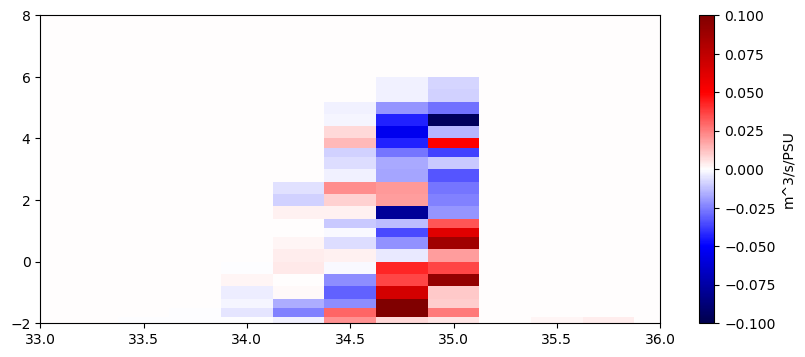

In [64]:
plt.pcolormesh(Sbin2,Tbin2,G_TS.T*1e-6,cmap='seismic',vmin = -0.1,vmax = 0.1)
plt.colorbar(label="m^3/s/PSU")
plt.xlim(33,36)
plt.ylim(-2,8)

Text(0.5, 1.0, 'resid')

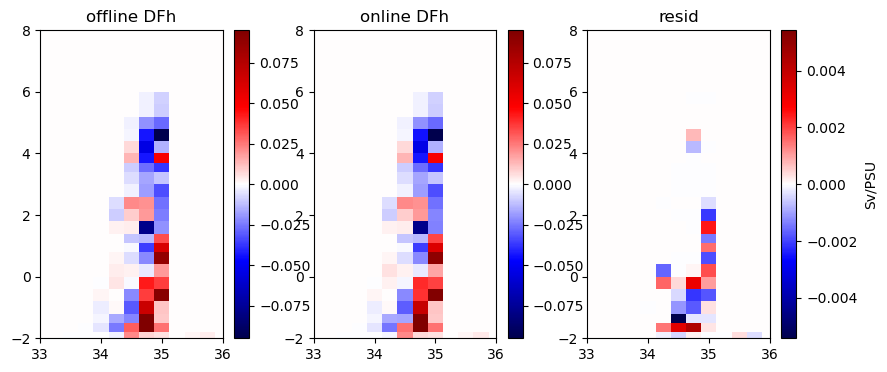

In [65]:
# do the same process with total tend for heat and see if these are the same
# Is this the same thing? make a figure
nbasin="BarentsS"
DFoff = G_TS.T * 1e-6
DFon = Jy[nbasin][tsstr[1]]['LaTh_TS'].T
resid = DFoff-DFon

fig = plt.figure()

ax = plt.subplot(131)
cb = ax.pcolormesh(Sbin2,Tbin2,DFoff,cmap='seismic',vmin = np.nanmin(DFoff),vmax = -np.nanmin(DFoff))
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
ax.set_title("offline DFh")

ax = plt.subplot(132)
cb = ax.pcolormesh(Sbin2,Tbin2,DFon,cmap='seismic',vmin = np.nanmin(DFon),vmax = -np.nanmin(DFon))
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
ax.set_title("online DFh")

ax = plt.subplot(133)
cb = ax.pcolormesh(Sbin2,Tbin2,resid,cmap='seismic',vmin = np.nanmin(resid),vmax = -np.nanmin(resid))
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
ax.set_title("resid")

In [106]:
# plt.pcolormesh(G_Tend)
np.where(G_Tend !=0) # indices in T, indices in S

(array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  3,
         3,  3,  3,  3,  4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  6,  6,  6,
         6,  6,  7,  7,  7,  7,  8,  8,  8,  8,  9,  9,  9, 10, 10, 10, 11,
        11, 11, 11, 12, 12, 12, 12, 13, 13, 13, 13, 14, 14, 14, 15, 15, 15,
        16, 16, 16, 17, 17, 17, 18, 18, 18, 19, 19, 19, 20, 20, 20, 21, 21,
        22, 22]),
 array([85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 86, 87, 88, 89, 90, 91, 87,
        88, 89, 90, 91, 87, 88, 89, 90, 91, 87, 88, 89, 90, 91, 87, 88, 89,
        90, 91, 88, 89, 90, 91, 88, 89, 90, 91, 89, 90, 91, 89, 90, 91, 88,
        89, 90, 91, 88, 89, 90, 91, 88, 89, 90, 91, 89, 90, 91, 89, 90, 91,
        89, 90, 91, 89, 90, 91, 89, 90, 91, 89, 90, 91, 89, 90, 91, 90, 91,
        90, 91]))

Text(0.5, 1.0, 'resid')

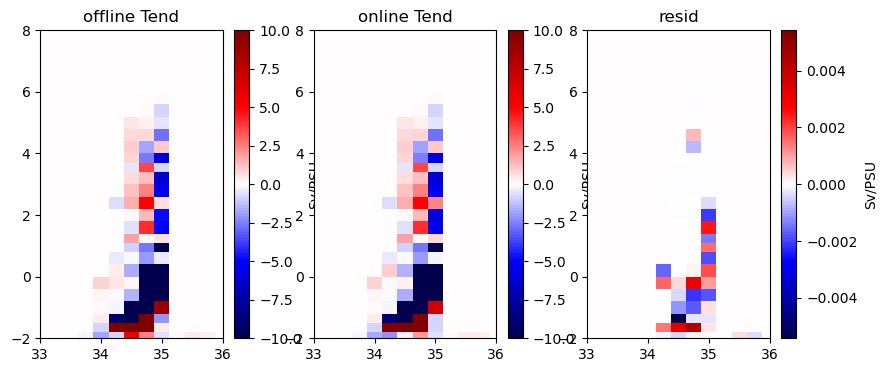

In [66]:
# do the same process for total tendency (these are not the same).

# LTto_TS tend online

# do the same process with total tend for heat and see if these are the same
# Is this the same thing? make a figure
nbasin="BarentsS"
DFoff = G_TS.T * 1e-6
DFon = Jy[nbasin][tsstr[1]]['LaTh_TS'].T
resid = DFoff-DFon

fig = plt.figure()

# this is Jy!!!
ax = plt.subplot(131)
cb = ax.pcolormesh(Sbin2,Tbin2,G_Tend.T*1e-6,cmap='seismic',vmin =  -10,vmax = 10)
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
ax.set_title("offline Tend")

ax = plt.subplot(132)
cb = ax.pcolormesh(Sbin2,Tbin2,LTto_TS.T,cmap='seismic',vmin = -10,vmax =10)
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
ax.set_title("online Tend")

ax = plt.subplot(133)
cb = ax.pcolormesh(Sbin2,Tbin2,resid,cmap='seismic',vmin = np.nanmin(resid),vmax = -np.nanmin(resid))
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
ax.set_title("resid")

In [67]:
# these are mostly the same but not exactly. but anyways. we can move on I think

In [68]:
# to do now

# get the M term in TS space from G as done before (we need to replace the other ADV terms in J)
# we can follow the same recipe as before.
# check on the dv/dt - what is this meant to be from the two tendency terms and can we create this from the other form
# a fast way to check this might be to load the J terms from layers and plot these against M to see if we can create this.

In [69]:
# we want to create the four M terms as gates in the theta budget

In [70]:
# load the Jx terms from the file
filename = "Jx_miniaste_BarentsS.npz"
matpath = "/scratch2/mmurakami/aste_90x150x60/"
matpath += "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"

npz = np.load(matpath + filename, allow_pickle=True)

Jx = {}
# Jx["unit"] = str(npz["unit"])  # stored as 0-d array / stringy object

# this is the nested dict, stored as a 0-d object array
Jx["BarentsS"] = npz["BarentsS"].item()

npz.close()

In [71]:
Jx['BarentsS']['0000000004'].keys()   # Sv/degC

dict_keys(['G_S', 'LSto_TS', 'LSza_TS', 'LSha_TS', 'LaSz_TS', 'LaSh_TS', 'LaSs_TS', 'residS'])

In [72]:
Jy['BarentsS']['0000000004'].keys()   # Sv/PSU

dict_keys(['G_T', 'LTto_TS', 'LTza_TS', 'LTha_TS', 'LaTz_TS', 'LaTh_TS', 'LaTs_TS', 'residT'])

In [73]:
# I think perhaps we don't want to move onto the gates yet. Let's just stay with layers output alone
# but no this will not work.
# try to make an example dV/dt with the tendencies, and a dV/dt with the ADV terms

In [74]:
# somehow I doubt this will work

In [75]:
Jy_tend = Jy['BarentsS']['0000000004']['LTto_TS']  # Sv/PSU
Jx_tend = Jx['BarentsS']['0000000004']['LSto_TS']  # Sv/degC

# we want to normalize by binwidthT1 and binwidthS1
# 


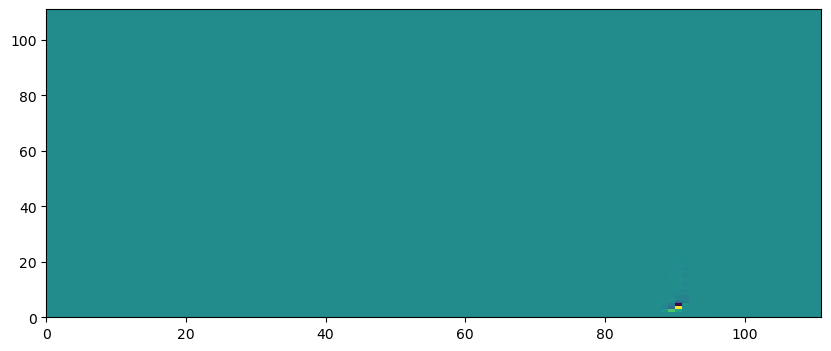

In [76]:
plt.pcolormesh(Jy_tend)

(-2.0, 9.0)

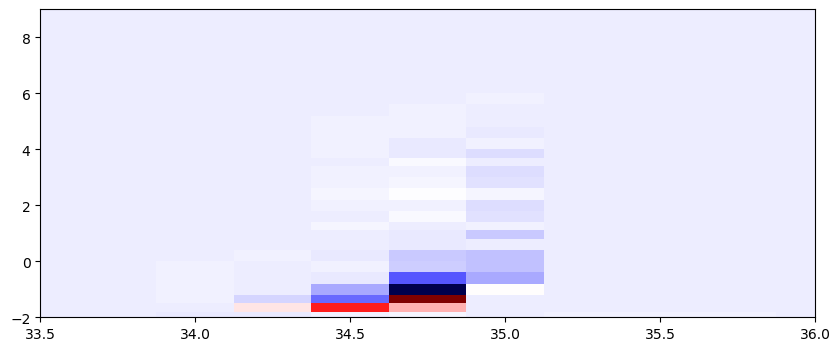

In [77]:
plt.pcolormesh(Sbin2,Tbin2,Jy_tend.T,cmap='seismic')
plt.xlim(33.5,36)
plt.ylim(-2,9)

## we confirmed that the J terms are the same, but we're looking here for the mass budget

In [78]:
# if we take the diverence of these, we get something of shape 110,110
# the divergence of the two tendencies will be equal to the other terms.
# the question is, does the divergence of the ADVh term resemble the T-S diagram of the M term at the gates?
# termsT3D['ADVh'].shape

In [79]:
# calculate the TS diagrams of the gates
# do this and check that the overall sum in TS space (is the same as the created TS diagram)

# STEPS

# create the TS diagram for ADVhT -- check this is the same as layers
# we need to make an array of 111,111 (see next line) which is DFhT_offline binned by cell center
# this is first in units of degC.m^3/s so we need to divide by binwidthT1 and binwidthS1
mymsk3d = np.tile(mymsk[np.newaxis,:,:],(nz,1,1))

dF_TS = np.zeros((nT-1, nS-1), dtype=float)
G_TS  = np.zeros((nT-1, nS-1), dtype=float)
L_TS  = np.zeros((nT-1, nS-1), dtype=int)

# Flatten so we don't have to loop thorugh zyx
T_flat   = np.ravel(THETA * mymsk3d, order="F")
S_flat   = np.ravel(SALT  * mymsk3d, order="F")
ADVh_flat = np.ravel(termsT3D['ADVh']  * mymsk3d, order="F")

# 2D binning via bin index lookup (faster than nested np.where) as in previous loop (in create_aste90_layers.py)
iT = np.searchsorted(binmidT, T_flat, side="right") - 1
iS = np.searchsorted(binmidS, S_flat, side="right") - 1

# Keep only points that land in a valid interior bin
ok = (iT >= 0) & (iT < nT-1) & (iS >= 0) & (iS < nS-1) & np.isfinite(ADVh_flat)
iT = iT[ok]
iS = iS[ok]
vals = ADVh_flat[ok]

# Accumulate sums and counts into (T,S) bins
np.add.at(dF_TS, (iT, iS), vals)
np.add.at(L_TS,  (iT, iS), 1)

# Normalize by BOTH bin widths (outer product gives (nT-1, nS-1))
dA = binwidthT1[:, None] * binwidthS1[None, :]
G_TS = dF_TS / dA    # gives units of m^3/s/PSU


# do the same thing for tendency
tend_flat = np.ravel(termsT3D["tend"]  * mymsk3d, order="F")
vals_tend = tend_flat[ok]
dF_Tend = np.zeros((nT-1, nS-1), dtype=float)
np.add.at(dF_Tend, (iT, iS), vals_tend)
G_Tend = dF_Tend / dA    # gives units of m^3/s/PSU



In [80]:
# Jy[nbasin][tsstr[1]].keys()

Text(0.5, 1.0, 'resid')

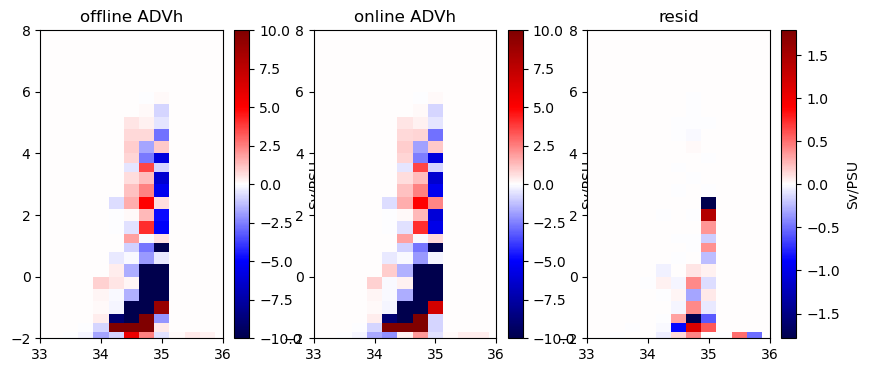

In [81]:
# do the same process for total tendency (these are not the same).

# LTto_TS tend online

# do the same process with total tend for heat and see if these are the same
# Is this the same thing? make a figure
nbasin="BarentsS"
DFoff = G_TS.T * 1e-6
DFon = Jy[nbasin][tsstr[1]]['LTha_TS'].T
resid = DFoff-DFon

fig = plt.figure()

ax = plt.subplot(131)
cb = ax.pcolormesh(Sbin2,Tbin2,G_Tend.T*1e-6,cmap='seismic',vmin =  -10,vmax = 10)
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
ax.set_title("offline ADVh")

ax = plt.subplot(132)
cb = ax.pcolormesh(Sbin2,Tbin2,LTto_TS.T,cmap='seismic',vmin = -10,vmax =10)
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
ax.set_title("online ADVh")

ax = plt.subplot(133)
cb = ax.pcolormesh(Sbin2,Tbin2,resid,cmap='seismic',vmin = np.nanmin(resid),vmax = -np.nanmin(resid))
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
ax.set_title("resid")

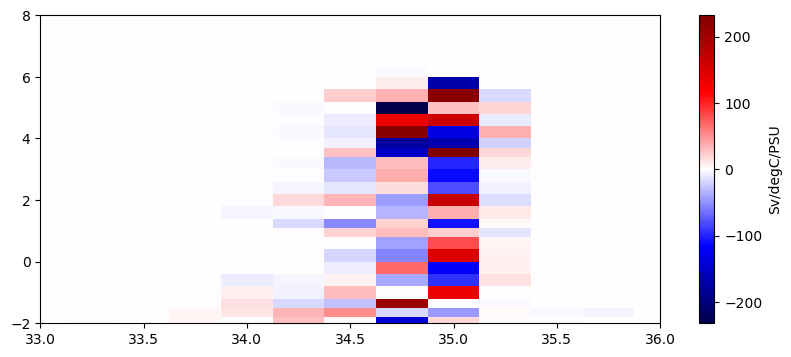

In [89]:
# create the convergence of the ADV terms in T and S
# Jy_ADVh: Sv/PSU  (function of T,S on bin centers)
# Jx_ADVh: Sv/degC (function of T,S on bin centers)
Jy_ADVh = Jy[nbasin][tsstr[1]]['LTha_TS'].T
Jx_ADVh = Jx[nbasin][tsstr[1]]['LSha_TS'].T

# bin centers for plotting (what you already use)
# Sbin2, Tbin2 are 2D grids for pcolormesh cell corners/edges
# binwidthS1 (nS-1,) and binwidthT1 (nT-1,) are bin widths at cell centers

dS = binwidthS1          # (nS-1,)
dT = binwidthT1          # (nT-1,)

# --- helper: face-flux divergence that preserves (nT-1, nS-1) shape ---
def div_ST(Jx_Sv_per_degC, Jy_Sv_per_PSU, dS, dT):
    """
    Returns divergence in Sv/(degC*PSU) on cell centers (nT-1, nS-1)
    using a conservative face-flux form with zero flux on outer S/T edges.
    """
    nT, nS = Jx_Sv_per_degC.shape

    # Jx lives as Sv/degC; divergence needs d/dS -> Sv/(degC*PSU)
    # build S-faces (nT, nS+1)
    Jx_face = np.zeros((nT, nS + 1))
    Jx_face[:, 1:nS] = 0.5 * (Jx_Sv_per_degC[:, :-1] + Jx_Sv_per_degC[:, 1:])  # interior
    # edges Jx_face[:,0] and Jx_face[:,-1] stay zero (no-flux in S)

    # Jy lives as Sv/PSU; divergence needs d/dT -> Sv/(degC*PSU)
    # build T-faces (nT+1, nS)
    Jy_face = np.zeros((nT + 1, nS))
    Jy_face[1:nT, :] = 0.5 * (Jy_Sv_per_PSU[:-1, :] + Jy_Sv_per_PSU[1:, :])    # interior
    # edges Jy_face[0,:] and Jy_face[-1,:] stay zero (no-flux in T)

    # finite-volume differences (broadcast widths)
    dJx_dS = (Jx_face[:, 1:] - Jx_face[:, :-1]) / dS[None, :]     # (nT, nS)
    dJy_dT = (Jy_face[1:, :] - Jy_face[:-1, :]) / dT[:, None]     # (nT, nS)

    return dJx_dS + dJy_dT  # Sv/(degC*PSU)

# convergence = -divergence
conv_ADVh = -div_ST(Jx_ADVh, Jy_ADVh, dS, dT)   # Sv/(degC*PSU)

# If you want Sv per bin (i.e., dV/dt contribution per (T,S) cell), multiply by bin areas:
conv_ADVh_Sv_per_bin = conv_ADVh * (dT[:, None] * dS[None, :])    # Sv

# plot like your resid (choose which one matches your resid units)
resid = conv_ADVh  # or conv_ADVh_Sv_per_bin
fig = plt.figure()
ax = plt.subplot(111)
cb = ax.pcolormesh(Sbin2, Tbin2, conv_ADVh,
                   cmap='seismic',
                   vmin=np.nanmin(resid), vmax=-np.nanmin(resid))

ax.set_xlim(33,36)
ax.set_ylim(-2,8)
plt.colorbar(cb,label="Sv/degC/PSU")

In [46]:
# create the TS diagram for M terms for ADVh



In [82]:
# check again the overall sum of the above is the same sum as before
# show the divergence plot in TS space for the ADVh layers terms -- compare this to the TS diagram for M terms
# I do not think these will be the same

In [ ]:
# we need dv/dt of the mass.